## Part 1: Loading and Cleaning with Pandas 
Read in the `goodreads.csv` file, examine the data, and do any necessary data cleaning. 

Here is a description of the columns (in order) present in this csv file:

```
rating: the average rating on a 1-5 scale achieved by the book
review_count: the number of Goodreads users who reviewed this book
isbn: the ISBN code for the book
booktype: an internal Goodreads identifier for the book
author_url: the Goodreads (relative) URL for the author of the book
year: the year the book was published
genre_urls: a string with '|' separated relative URLS of Goodreads genre pages
dir: a directory identifier internal to the scraping code
rating_count: the number of ratings for this book (this is different from the number of reviews)
name: the name of the book
```

Let us see what issues we find with the data and resolve them.  



----

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
pd.set_option('display.width', 500)
pd.set_option('display.max_columns', 100)

### Cleaning: Reading in the data
We read in and clean the data from `goodreads.csv`.

In [2]:
#Read the data into a dataframe
df = pd.read_csv("data/goodreads.csv")

#TODO Examine the first few rows of the dataframe


We are missing the column names. We need to add these in. But what are they?

Here is a list of them in order:

`["rating", 'review_count', 'isbn', 'booktype','author_url', 'year', 'genre_urls', 'dir','rating_count', 'name']`

<div class="exercise"><b>Exercise</b></div>
Use these to load the dataframe properly! And then "head" the dataframe (you will need to look at the read_csv docs)


In [3]:
# your code here
df = pd.read_csv("data/goodreads.csv", header=None,
               names=["rating", 'review_count', 'isbn', 'booktype','author_url', 'year', 'genre_urls', 'dir','rating_count', 'name']
)

#Examine the first few rows of the dataframe
df.head()

,rating,review_count,isbn,booktype,author_url,year,genre_urls,dir,rating_count,name
0,4.40,136455.0,0439023483,good_reads:book,https://www.goodreads.com/author/show/153394.S...,2008.0,/genres/young-adult|/genres/science-fiction|/g...,dir01/2767052-the-hunger-games.html,2958974.0,"The Hunger Games (The Hunger Games, #1)"
1,4.41,16648.0,0439358078,good_reads:book,https://www.goodreads.com/author/show/1077326....,2003.0,/genres/fantasy|/genres/young-adult|/genres/fi...,dir01/2.Harry_Potter_and_the_Order_of_the_Phoe...,1284478.0,Harry Potter and the Order of the Phoenix (Har...
2,3.56,85746.0,0316015849,good_reads:book,https://www.goodreads.com/author/show/941441.S...,2005.0,/genres/young-adult|/genres/fantasy|/genres/ro...,dir01/41865.Twilight.html,2579564.0,"Twilight (Twilight, #1)"
3,4.23,47906.0,0061120081,good_reads:book,https://www.goodreads.com/author/show/1825.Har...,1960.0,/genres/classics|/genres/fiction|/genres/histo...,dir01/2657.To_Kill_a_Mockingbird.html,2078123.0,To Kill a Mockingbird
4,4.23,34772.0,0679783261,good_reads:book,https://www.goodreads.com/author/show/1265.Jan...,1813.0,/genres/classics|/genres/fiction|/genres/roman...,dir01/1885.Pride_and_Prejudice.html,1388992.0,Pride and Prejudice


### Cleaning: Examing the dataframe - quick checks

We should examine the dataframe to get an overall sense of the content.

A quick dtype check is useful because pandas will often guess the wrong type when the raw file contains messy values. For example, if a column looks numeric but includes blanks, strings like "N/A", or odd formatting, pandas may treat it as `object` instead of `int` or `float`. That is usually the first sign that the data needs cleaning.

<div class="exercise"><b>Exercise</b></div>
Lets check the types of the columns. What do you find?

In [4]:
# your code here
####### 
df.dtypes
#######

rating          float64
review_count    float64
isbn             object
booktype         object
author_url       object
year            float64
genre_urls       object
dir              object
rating_count    float64
name             object
dtype: object

*your answer here*


There are a couple more quick sanity checks to perform on the dataframe. 

In [5]:

print(df.shape)
df.columns

(6000, 10)


Index(['rating', 'review_count', 'isbn', 'booktype', 'author_url', 'year', 'genre_urls', 'dir', 'rating_count', 'name'], dtype='object')

### Cleaning: Examining the dataframe - a deeper look

Beyond performing checking some quick general properties of the data frame and looking at the first $n$ rows, we can dig a bit deeper into the values being stored. If you haven't already, check to see if there are any missing values in the data frame.

Let's see for a column which seemed OK to us.

In [6]:
#Get a sense of how many missing values there are in the dataframe.
np.sum([df.rating.isnull()])

np.int64(2)

In [7]:
#Try to locate where the missing values occur
df[df.rating.isnull()]

,rating,review_count,isbn,booktype,author_url,year,genre_urls,dir,rating_count,name
3643,NaN,NaN,NaN,NaN,NaN,NaN,NaN,dir37/9658936-harry-potter.html,NaN,NaN
5282,NaN,NaN,NaN,NaN,NaN,NaN,NaN,dir53/113138.The_Winner.html,NaN,NaN


How does `pandas` or `numpy` handle missing values when we try to compute with data sets that include them?

We'll now check if any of the other suspicious columns have missing values.  Let's look at `year` and `review_count` first.

One thing you can do is to try and convert to the type you expect the column to be. If something goes wrong, it likely means your data are bad.

Lets test for missing data:

In [8]:
df[df.year.isnull()]

,rating,review_count,isbn,booktype,author_url,year,genre_urls,dir,rating_count,name
2442,4.23,526.0,NaN,good_reads:book,https://www.goodreads.com/author/show/623606.A...,NaN,/genres/religion|/genres/islam|/genres/non-fic...,dir25/1301625.La_Tahzan.html,4134.0,La Tahzan
2869,4.61,2.0,NaN,good_reads:book,https://www.goodreads.com/author/show/8182217....,NaN,NaN,dir29/22031070-my-death-experiences---a-preach...,23.0,My Death Experiences - A Preacherâs 18 Apoca...
3643,NaN,NaN,NaN,NaN,NaN,NaN,NaN,dir37/9658936-harry-potter.html,NaN,NaN
5282,NaN,NaN,NaN,NaN,NaN,NaN,NaN,dir53/113138.The_Winner.html,NaN,NaN
5572,3.71,35.0,8423336603,good_reads:book,https://www.goodreads.com/author/show/285658.E...,NaN,/genres/fiction,dir56/890680._rase_una_vez_el_amor_pero_tuve_q...,403.0,Ãrase una vez el amor pero tuve que matarlo. ...
5658,4.32,44.0,NaN,good_reads:book,https://www.goodreads.com/author/show/25307.Ro...,NaN,/genres/fantasy|/genres/fantasy|/genres/epic-f...,dir57/5533041-assassin-s-apprentice-royal-assa...,3850.0,Assassin's Apprentice / Royal Assassin (Farsee...
5683,4.56,204.0,NaN,good_reads:book,https://www.goodreads.com/author/show/3097905....,NaN,/genres/fantasy|/genres/young-adult|/genres/ro...,dir57/12474623-tiger-s-dream.html,895.0,"Tiger's Dream (The Tiger Saga, #5)"


### Cleaning: Dealing with Missing Values
How should we interpret 'missing' or 'invalid' values in the data (hint: look at where these values occur)? One approach is to simply exclude them from the dataframe. Is this appropriate for all 'missing' or 'invalid' values?

This is the point where we often need to pause and think like a data analyst rather than just "run a command." A missing value is not always a sign that the row should be discarded. Sometimes it is a harmless gap, and sometimes it means the entire observation is unusable.

In this dataset, the rows with missing or invalid `year` values are clearly not useful for a book-level analysis, so dropping them makes sense. But we should always inspect the rows first and ask whether the issue affects just one field or the whole record. Later in the course, we will also talk about imputation, which is when we fill missing values instead of removing them.

The key idea is: cleaning is about making informed decisions, not just deleting anything that looks odd.


In [9]:
#Treat the missing or invalid values in your dataframe
####### 

df = df[df.year.notnull()]

Ok so we have done some cleaning. What do things look like now? Notice the float has not yet changed.

In [10]:
df.dtypes

rating          float64
review_count    float64
isbn             object
booktype         object
author_url       object
year            float64
genre_urls       object
dir              object
rating_count    float64
name             object
dtype: object

In [11]:
print(np.sum(df.year.isnull()))
print(np.sum(df.rating_count.isnull())) 
print(np.sum(df.review_count.isnull())) 
# We removed seven rows
df.shape

0
0
0


(5993, 10)

Suspect observations for rating and rating_count were removed as well

<div class="exercise"><b>Exercise</b></div>

Ok so lets fix those types. Convert them to ints. If the type conversion fails, we now know we have further problems.

A good habit here is to check the column before and after conversion. If a column is supposed to be a count or a year, we expect integer-like values. If pandas cannot convert something cleanly, that usually means there are still bad entries in the data that need to be handled explicitly.

In real projects, we often use `pd.to_numeric(..., errors='coerce')` to force conversion and turn bad values into `NaN`, which makes it much easier to inspect what still needs cleaning.


In [12]:
# your code here
df.rating_count = pd.to_numeric(df.rating_count, errors='coerce')
df.review_count = pd.to_numeric(df.review_count, errors='coerce')
df.year = pd.to_numeric(df.year, errors='coerce')   

Once you do this, we seem to be good on these columns (no errors in conversion). Lets look:

In [13]:
df.dtypes

rating          float64
review_count    float64
isbn             object
booktype         object
author_url       object
year            float64
genre_urls       object
dir              object
rating_count    float64
name             object
dtype: object

Some of the other colums that should be strings have NaN.

In [14]:
df.loc[df.genre_urls.isnull(), 'genre_urls']=""
df.loc[df.isbn.isnull(), 'isbn']=""

##  Part 2: Parsing and Completing the Data Frame 

We will parse the `author` column from the author_url and `genres` column from the genre_urls. Keep the `genres` column as a string separated by '|'.

We will use panda's `map` to assign new columns to the dataframe.  

Examine an example `author_url` and reason about which sequence of string operations must be performed in order to isolate the author's name.

In [15]:
#Get the first author_url
test_string = df.author_url[0]
test_string

'https://www.goodreads.com/author/show/153394.Suzanne_Collins'

In [16]:
#Test out some string operations to isolate the author name

test_string.split('/')[-1].split('.')[1:][0]

'Suzanne_Collins'

<div class="exercise"><b>Exercise</b></div>

Lets wrap the above code into a function which we will then use

In [17]:
# Write a function that accepts an author url and returns the author's name based on your experimentation above
def get_author(url):
    # your code here
    name = url.split('/')[-1].split('.')[1:][0]
    ####### 
    return name

In [18]:
#Apply the get_author function to the 'author_url' column using '.map' 
#and add a new column 'author' to store the names
df['author'] = df.author_url.map(get_author)
df.author[0:5]

0    Suzanne_Collins
1        J_K_Rowling
2    Stephenie_Meyer
3         Harper_Lee
4        Jane_Austen
Name: author, dtype: object

<div class="exercise"><b>Exercise</b></div>

Now parse out the genres from `genre_url`.  

This is a little more complicated because there be more than one genre.


In [19]:

df.genre_urls.head()

0    /genres/young-adult|/genres/science-fiction|/g...
1    /genres/fantasy|/genres/young-adult|/genres/fi...
2    /genres/young-adult|/genres/fantasy|/genres/ro...
3    /genres/classics|/genres/fiction|/genres/histo...
4    /genres/classics|/genres/fiction|/genres/roman...
Name: genre_urls, dtype: object

In [20]:
# your code here
#Examine some examples of genre_urls

#Test out some string operations to isolate the genre name
test_genre_string=df.genre_urls[0]
genres = test_genre_string.strip().split('|')
for e in genres:
    print(e.split('/')[-1])
    "|".join(genres)

young-adult
science-fiction
dystopia
fantasy
science-fiction
romance
adventure
book-club
young-adult
teen
apocalyptic
post-apocalyptic
action


<div class="exercise"><b>Exercise</b></div>

Write a function that accepts a genre url and returns the genre name based on your experimentation above



In [24]:
def split_and_join_genres(url):
    # your code here
    genres = url.strip().split('|')
    genres = [e.split('/')[-1] for e in genres]
    return "|".join(genres)

Test your function

In [25]:
split_and_join_genres("/genres/young-adult|/genres/science-fiction")

'young-adult|science-fiction'

In [26]:
split_and_join_genres("")

''

<div class="exercise"><b>Exercise</b></div>

Use map again to create a new "genres" column

In [27]:

df['genres']=df.genre_urls.map(split_and_join_genres)
df.head()

,rating,review_count,isbn,booktype,author_url,year,genre_urls,dir,rating_count,name,author,genres
0,4.40,136455.0,0439023483,good_reads:book,https://www.goodreads.com/author/show/153394.S...,2008.0,/genres/young-adult|/genres/science-fiction|/g...,dir01/2767052-the-hunger-games.html,2958974.0,"The Hunger Games (The Hunger Games, #1)",Suzanne_Collins,young-adult|science-fiction|dystopia|fantasy|s...
1,4.41,16648.0,0439358078,good_reads:book,https://www.goodreads.com/author/show/1077326....,2003.0,/genres/fantasy|/genres/young-adult|/genres/fi...,dir01/2.Harry_Potter_and_the_Order_of_the_Phoe...,1284478.0,Harry Potter and the Order of the Phoenix (Har...,J_K_Rowling,fantasy|young-adult|fiction|fantasy|magic|chil...
2,3.56,85746.0,0316015849,good_reads:book,https://www.goodreads.com/author/show/941441.S...,2005.0,/genres/young-adult|/genres/fantasy|/genres/ro...,dir01/41865.Twilight.html,2579564.0,"Twilight (Twilight, #1)",Stephenie_Meyer,young-adult|fantasy|romance|paranormal|vampire...
3,4.23,47906.0,0061120081,good_reads:book,https://www.goodreads.com/author/show/1825.Har...,1960.0,/genres/classics|/genres/fiction|/genres/histo...,dir01/2657.To_Kill_a_Mockingbird.html,2078123.0,To Kill a Mockingbird,Harper_Lee,classics|fiction|historical-fiction|academic|s...
4,4.23,34772.0,0679783261,good_reads:book,https://www.goodreads.com/author/show/1265.Jan...,1813.0,/genres/classics|/genres/fiction|/genres/roman...,dir01/1885.Pride_and_Prejudice.html,1388992.0,Pride and Prejudice,Jane_Austen,classics|fiction|romance|historical-fiction|li...


Finally, let's pick an author at random so we can see the results of the transformations.  Scroll to see the `author` and `genre` columns that we added to the dataframe.

In [28]:
df[df.author == "Marguerite_Yourcenar"]

,rating,review_count,isbn,booktype,author_url,year,genre_urls,dir,rating_count,name,author,genres
1014,4.23,483.0,0374529264,good_reads:book,https://www.goodreads.com/author/show/7732.Mar...,1951.0,/genres/historical-fiction|/genres/fiction|/ge...,dir11/12172.Memoirs_of_Hadrian.html,6258.0,Memoirs of Hadrian,Marguerite_Yourcenar,historical-fiction|fiction|cultural|france|cla...
5620,4.11,74.0,2070367983,good_reads:book,https://www.goodreads.com/author/show/7732.Mar...,1968.0,/genres/fiction|/genres/historical-fiction|/ge...,dir57/953435.L_uvre_au_noir.html,1601.0,L'Åuvre au noir,Marguerite_Yourcenar,fiction|historical-fiction|cultural|france|eur...


Let us delete the `genre_urls` column.

In [29]:
del df['genre_urls']

And then save the dataframe out!

In [30]:
df.to_csv("data/cleaned-goodreads.csv", index=False, header=True)

---

## Part 3: Grouping 

It appears that some books were written in negative years!  Print out the observations that correspond to negative years.  What do you notice about these books?  

In [31]:
# your code here
df[df.year < 0].head()
#These are books written before the Common Era (BCE, equivalent to BC).

,rating,review_count,isbn,booktype,author_url,year,dir,rating_count,name,author,genres
47,3.68,5785.0,0143039954,good_reads:book,https://www.goodreads.com/author/show/903.Homer,-800.0,dir01/1381.The_Odyssey.html,560248.0,The Odyssey,Homer,classics|fiction|poetry|fantasy|mythology|acad...
246,4.01,365.0,0147712556,good_reads:book,https://www.goodreads.com/author/show/903.Homer,-800.0,dir03/1375.The_Iliad_The_Odyssey.html,35123.0,The Iliad/The Odyssey,Homer,classics|fantasy|mythology|fantasy|academic|sc...
455,3.85,1499.0,0140449140,good_reads:book,https://www.goodreads.com/author/show/879.Plato,-380.0,dir05/30289.The_Republic.html,82022.0,The Republic,Plato,philosophy|classics|non-fiction|politics|histo...
596,3.77,1240.0,0679729526,good_reads:book,https://www.goodreads.com/author/show/919.Virgil,-29.0,dir06/12914.The_Aeneid.html,60308.0,The Aeneid,Virgil,classics|poetry|fiction|fantasy|mythology|acad...
629,3.64,1231.0,1580495931,good_reads:book,https://www.goodreads.com/author/show/1002.Sop...,-429.0,dir07/1554.Oedipus_Rex.html,93192.0,Oedipus Rex,Sophocles,classics|plays|drama|fiction|academic|school|l...


We can determine the "best book" by year! For this we use Pandas groupby. Groupby allows grouping a dataframe by any (usually categorical) variable.

In [32]:
dfgb_author = df.groupby('author')
type(dfgb_author)

pandas.core.groupby.generic.DataFrameGroupBy

Perhaps we want the number of books each author wrote

In [33]:
dfgb_author.count()

,rating,review_count,isbn,booktype,author_url,year,dir,rating_count,name,genres
author,,,,,,,,,,
A_A_Milne,6,6,6,6,6,6,6,6,6,6
A_G_Howard,1,1,1,1,1,1,1,1,1,1
A_J_Cronin,1,1,1,1,1,1,1,1,1,1
A_J_Jacobs,1,1,1,1,1,1,1,1,1,1
A_J_Salt,1,1,1,1,1,1,1,1,1,1
...,...,...,...,...,...,...,...,...,...,...
_,42,42,42,42,42,42,42,42,42,42
_gota_Krist_f,1,1,1,1,1,1,1,1,1,1
_mile_Zola,4,4,4,4,4,4,4,4,4,4


Lots of useless info there. One column should suffice

In [34]:
dfgb_author['author'].count()

author
A_A_Milne                 6
A_G_Howard                1
A_J_Cronin                1
A_J_Jacobs                1
A_J_Salt                  1
                         ..
_                        42
_gota_Krist_f             1
_mile_Zola                4
_ric_Emmanuel_Schmitt     1
_sne_Seierstad            1
Name: author, Length: 2645, dtype: int64

Perhaps you want more detailed info...

In [35]:
dfgb_author[['rating', 'rating_count', 'review_count', 'year']].describe()

rating                                                        rating_count                                                                             review_count                                                                      year                                                                   
                       count      mean       std   min     25%    50%     75%   max        count          mean           std      min       25%      50%       75%       max        count         mean          std     min      25%     50%      75%     max count         mean         std     min      25%     50%      75%     max
author                                                                                                                                                                                                                                                                                                                                
A_A_Milne                6.0  4.365000  0.078677  4.25  4.3275  4.365  4.4025  4.48          6.0  47842.333333  57135.314010    544.0  15559.50  30547.0  50401.25  157833.0          6.0   543.000000   682.473150     1.0   219.50   309.5   499.25  1886.0   6.0  1944.166667   29.294482  1926.0  1926.25  1927.5  1952.75  1997.0
A_G_Howard               1.0  4.020000       NaN  4.02  4.0200  4.020  4.0200  4.02          1.0  17073.000000           NaN  17073.0  17073.00  17073.0  17073.00   17073.0          1.0  3194.000000          NaN  3194.0  3194.00  3194.0  3194.00  3194.0   1.0  2013.000000         NaN  2013.0  2013.00  2013.0  2013.00  2013.0
A_J_Cronin               1.0  4.220000       NaN  4.22  4.2200  4.220  4.2200  4.22          1.0   1015.000000           NaN   1015.0   1015.00   1015.0   1015.00    1015.0          1.0   109.000000          NaN   109.0   109.00   109.0   109.00   109.0   1.0  1941.000000         NaN  1941.0  1941.00  1941.0  1941.00  1941.0
A_J_Jacobs               1.0  3.750000       NaN  3.75  3.7500  3.750  3.7500  3.75          1.0  39489.000000           NaN  39489.0  39489.00  39489.0  39489.00   39489.0          1.0  4371.000000          NaN  4371.0  4371.00  4371.0  4371.00  4371.0   1.0  2007.000000         NaN  2007.0  2007.00  2007.0  2007.00  2007.0
A_J_Salt                 1.0  4.940000       NaN  4.94  4.9400  4.940  4.9400  4.94          1.0     16.000000           NaN     16.0     16.00     16.0     16.00      16.0          1.0     6.000000          NaN     6.0     6.00     6.0     6.00     6.0   1.0  2014.000000         NaN  2014.0  2014.00  2014.0  2014.00  2014.0
...                      ...       ...       ...   ...     ...    ...     ...   ...          ...           ...           ...      ...       ...      ...       ...       ...          ...          ...          ...     ...      ...     ...      ...     ...   ...          ...         ...     ...      ...     ...      ...     ...
_                       42.0  3.988095  0.301211  3.15  3.8000  4.075  4.2075  4.47         42.0  11574.642857   9368.218450     10.0   4724.00   8709.5  15572.75   39302.0         42.0  1437.214286  1216.421371     1.0   534.75  1020.5  1745.75  4785.0  42.0  1998.904762   18.721071  1941.0  1994.75  2007.0  2010.75  2014.0
_gota_Krist_f            1.0  4.340000       NaN  4.34  4.3400  4.340  4.3400  4.34          1.0   2628.000000           NaN   2628.0   2628.00   2628.0   2628.00    2628.0          1.0   243.000000          NaN   243.0   243.00   243.0   243.00   243.0   1.0  1986.000000         NaN  1986.0  1986.00  1986.0  1986.00  1986.0
_mile_Zola               4.0  3.990000  0.100995  3.84  3.9750  4.035  4.0500  4.05          4.0   8358.250000   4553.226942   3594.0   5181.75   8095.0  11271.50   13649.0          4.0   283.750000   171.069917   125.0   189.50   243.5   337.75   523.0   4.0  1652.500000  456.345264   968.0  1649.75  1878.5  1881.25  1885.0
_ric_Emmanuel_Schmitt    1.0  4.160000       NaN  4.16  4.1600  4.160  4.1600  4.16          1.0  

You can also access a `groupby` dictionary style.

In [36]:
ratingdict = {}
for author, subset in dfgb_author:
    ratingdict[author] = (subset['rating'].mean(), subset['rating'].std())
ratingdict

{'A_A_Milne': (np.float64(4.364999999999999), 0.0786765530510839),
 'A_G_Howard': (np.float64(4.02), nan),
 'A_J_Cronin': (np.float64(4.22), nan),
 'A_J_Jacobs': (np.float64(3.75), nan),
 'A_J_Salt': (np.float64(4.94), nan),
 'A_Meredith_Walters': (np.float64(4.15), 0.16970562748477094),
 'A_N_Roquelaure': (np.float64(3.45), 0.2262741699796951),
 'A_S_Byatt': (np.float64(3.86), nan),
 'A_S_King': (np.float64(3.93), nan),
 'A_id_al_Qarni': (np.float64(4.050000000000001), 0.19798989873223347),
 'Abbi_Glines': (np.float64(4.179285714285713), 0.12916681436834276),
 'Abdul_Rahman_Munif': (np.float64(4.03), nan),
 'Abigail_Gibbs': (np.float64(3.82), nan),
 'Abigail_Roux': (np.float64(4.47), 0.22876479915697992),
 'Abigail_Thomas': (np.float64(3.68), nan),
 'Abolqasem_Ferdowsi': (np.float64(4.52), nan),
 'Abraham_Verghese': (np.float64(4.26), nan),
 'Abul_Hasan_Ali_Nadwi': (np.float64(4.15), nan),
 'Adam_Hochschild': (np.float64(4.14), nan),
 'Adam_Johnson': (np.float64(4.03), nan),
 'Adam_Le

<div class="exercise"><b>Exercise</b></div>

Lets get the best-rated book(s) for every year in our dataframe.

In [37]:
#Using .groupby, we can divide the dataframe into subsets by the values of 'year'.
#We can then iterate over these subsets
# your code here
for year, subset in df.groupby('year'):
    #Find the best book of the year

    bestbook = subset[subset.rating == subset.rating.max()]
    if bestbook.shape[0] > 1:
        print(year, bestbook.name.values, bestbook.rating.values)
    else:
        print(year, bestbook.name.values[0], bestbook.rating.values[0])

-1500.0 The Epic of Gilgamesh 3.6
-800.0 The Iliad/The Odyssey 4.01
-560.0 Aesop's Fables 4.03
-512.0 The Art of War 3.92
-500.0 The Bhagavad Gita 4.06
-458.0 The Oresteia 3.96
-442.0 Antigone 3.52
-440.0 The Histories 3.94
-431.0 Medea 3.8
-429.0 Oedipus Rex 3.64
-411.0 The History of the Peloponnesian War 3.84
-400.0 Complete Works 4.3
-390.0 Apology 4.11
-380.0 The Republic 3.85
-370.0 The Symposium 3.99
-360.0 Five Dialogues 4.07
-350.0 The Nicomachean Ethics 3.88
-29.0 The Aeneid 3.77
4.0 The Seven Spiritual Laws of Success 4.04
8.0 Metamorphoses 4.01
13.0 The Day Jesus Rode Into Croydon 3.85
100.0 The New Oxford Annotated Bible, New Revised Standard Version 4.3
121.0 The Twelve Caesars 4.02
130.0 Holy Bible 4.45
158.0 The Golden Ass 3.88
174.0 Meditations 4.16
200.0 The Garden of Eden 3.75
201.0 Fe Fi FOE Comes 4.37
213.0 NaÃ¯ve. Super 3.9
397.0 Confessions 3.82
632.0 The Quran 4.37
800.0 Beowulf 3.38
900.0 The Arabian Nights 4.04
968.0 La BÃªte humaine (Les Rougon-Macquart, #17)

## A quick intro to train/test split and sklearn

When we build a machine learning model, we do not want to test it on the same data we used to train it. If we do, the model can look much better than it really is because it has already seen those examples.

A common approach is to split the data into two parts:

- training set: used to fit the model
- test set: used to check how well the model generalises to new data

This is called a train/test split.

A simple explanation can be found here: https://www.geeksforgeeks.org/train-test-split-using-sklearn/

The basic idea is:
- fit the model on the training data
- evaluate it on the test data
- avoid using the test data during training

This helps us spot overfitting and gives us a more realistic idea of model performance.

A tiny example in sklearn looks like this:

```python
from sklearn.model_selection import train_test_split

X = df[['rating']]
y = df['rating_count']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(X_train.shape)
print(X_test.shape)
```

Here, `X` contains the features we use to predict, and `y` is the target variable. The `test_size=0.2` means 20% of the data is set aside for testing, while the remaining 80% is used to train the model. The `random_state` makes the split reproducible, so everyone gets the same result when they run the code.


In [38]:
from sklearn.model_selection import train_test_split

X = df[['rating']]
y = df['rating_count']

# make 90 percent of data as the training set and the rest as test set
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.10, random_state=42
)

print('X_train shape:', X_train.shape)
print('X_test shape:', X_test.shape)
print('y_train shape:', y_train.shape)
print('y_test shape:', y_test.shape)
print('Training rows:', len(X_train))
print('Test rows:', len(X_test))
print('Train mean rating:', round(X_train['rating'].mean(), 3))
print('Test mean rating:', round(X_test['rating'].mean(), 3))
print('Train target mean:', round(y_train.mean(), 3))
print('Test target mean:', round(y_test.mean(), 3))

X_train shape: (5393, 1)
X_test shape: (600, 1)
y_train shape: (5393,)
y_test shape: (600,)
Training rows: 5393
Test rows: 600
Train mean rating: 4.042
Test mean rating: 4.038
Train target mean: 50447.09
Test target mean: 57806.548


### Fitting a linear regression model

Now that the data is split, we fit a linear regression model that predicts `rating_count` from `rating`. The model learns a straight line of the form `y = slope * x + intercept` from the training data only.

After fitting we:
- look at the learned slope and intercept
- predict on both the training and the test set
- compare R-squared and mean squared error on the two sets.
- plot the fitted line against the actual test data

This cell is complete, you can just run it.

Coefficient (slope): -12078.882338487252
Intercept: 99275.40680831517
Train R^2: 0.001
Test R^2: 0.0
Train MSE: 18774051237.295
Test MSE: 20331419126.161


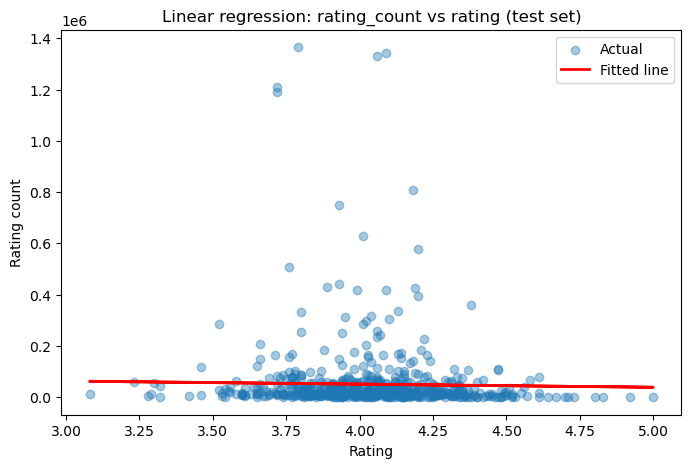

In [39]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# 1. Create the model and fit it on the training data only
linreg = LinearRegression()
linreg.fit(X_train, y_train)

# 2. Predict on both the training and the test set
y_pred_train = linreg.predict(X_train)
y_pred_test = linreg.predict(X_test)

# 3. Inspect the learned straight line: y = slope * rating + intercept
print("Coefficient (slope):", linreg.coef_[0])
print("Intercept:", linreg.intercept_)

# 4. Evaluate on both sets to check for overfitting
print("Train R^2:", round(r2_score(y_train, y_pred_train), 3))
print("Test R^2:", round(r2_score(y_test, y_pred_test), 3))
print("Train MSE:", round(mean_squared_error(y_train, y_pred_train), 3))
print("Test MSE:", round(mean_squared_error(y_test, y_pred_test), 3))

# 5. Plot the fitted line against the actual test data
plt.figure(figsize=(8, 5))
plt.scatter(X_test, y_test, alpha=0.4, label="Actual")
plt.plot(X_test, y_pred_test, color="red", linewidth=2, label="Fitted line")
plt.xlabel("Rating")
plt.ylabel("Rating count")
plt.title("Linear regression: rating_count vs rating (test set)")
plt.legend()
plt.show()